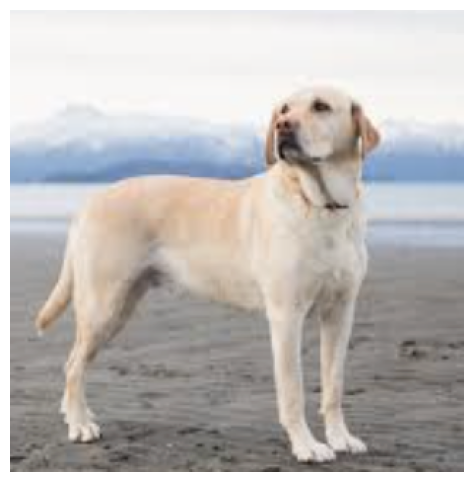

In [16]:
from PIL import Image

import matplotlib.pyplot as plt

path = "test_images/dog.png"

img = Image.open(path)
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis('off')
plt.show()

In [22]:
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import torch

# mps for apple silicon, cuda for nvidia gpu, otherwise cpu
# GPU performance is much better than CPU, so we want to use it if available
if torch.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

image_path = path
image = Image.open(image_path).convert("RGB")
#labels = ["tall room", "small room", "bright room", "dark room", "room with a window", "room without a window", "room with a door", "room without a door", "room with furniture", "room without furniture"]
labels = ["kitchen", "living room", "bedroom", "bathroom", "hallway", "garden", "house or building", "neighborhood", "floor plan", "under construction", "nothing to do with the property"]
#labels = ["interior design style is rustic", "interior design style is modern", "interior design style is scandinavian", "interior design style is industrial"]

# Processor returns CPU tensors -> move them to selected device
inputs = processor(text=labels, images=image, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

probs = outputs.logits_per_image.softmax(dim=1)

print('\nThis image belongs to the class:', labels[probs[0].argmax().item()])
print('\nDetailed probabilities:')
for label, prob in zip(labels, probs[0]):
    print(f"{prob.item():.4f}: {label}")

Using device: mps

This image belongs to the class: nothing to do with the property

Detailed probabilities:
0.0028: kitchen
0.0042: living room
0.0003: bedroom
0.0014: bathroom
0.0017: hallway
0.0037: garden
0.1859: house or building
0.0989: neighborhood
0.0012: floor plan
0.0401: under construction
0.6599: nothing to do with the property
